[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase1_memory_architectures/08_exercise.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


# Phase 1H — Hands-on Exercise: Build a Memory System

**Task:** build a memory system for a customer-support agent using **two techniques** from different
families. Test it on a sample conversation. Report what it remembers, what it forgets, and where it
would fail.

**Independent notebook** — runs standalone in Colab or locally.

In [1]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml", "openai"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
os.environ.setdefault("OPENAI_BASE_URL", "https://api.openai.com/v1")
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

from embedder import TfidfHashEmbedder
from llm_client import LLMConfig, make_client, OfflineLLMClient
from memory_core import MemoryRecord
from providers import build_provider
emb = TfidfHashEmbedder()
try:
    llm = make_client(LLMConfig(backend='openai-compatible' if os.environ.get('OPENAI_API_KEY') else 'offline',
                                base_url=os.environ.get('OPENAI_BASE_URL','https://api.openai.com/v1'),
                                model='gpt-4o'))
except Exception:
    llm = OfflineLLMClient()
print('LLM backend:', llm.backend, '| API key:', bool(os.environ.get('OPENAI_API_KEY')))
TURNS = [
 ("Alice", "Hi, I am Alice. I work as a data scientist at a health-tech startup in Berlin."),
 ("Bob", "I am Bob, an ML engineer in Athens. I prefer PyTorch."),
 ("Alice", "We deploy on Kubernetes and track runs with Weights and Biases."),
 ("Bob", "Our training run failed last night with CUDA OOM at batch 256."),
 ("Alice", "We hit that before. Reducing batch to 64 and enabling gradient checkpointing fixed it."),
 ("Bob", "Our best val_loss was 0.423 with lr=3e-4 and weight_decay=0.01."),
 ("Alice", "I live in Prenzlauer Berg. My favorite coffee shop is on Kollwitzplatz."),
 ("Bob", "Let us sync next Tuesday at 10am CET."),
]
records = [MemoryRecord(f"t{i}", f"{w}: {t}", {"session_id": "s1" if i < 4 else "s2"}) for i, (w, t) in enumerate(TURNS)]
print("setup OK | turns =", len(TURNS))


SOURCE_DIR = <repo>/source | found = True | IN_COLAB = False
LLM backend: offline | API key: False
setup OK | turns = 8


## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or a local file) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete the saved config file shown below.

In [2]:
# === Set up your LLM at the beginning: base URL, API key, model ===
# First run: you are prompted for the 3 values (API key hidden). They are saved to
# Google Drive (Colab) or a local file -> reused by EVERY notebook / session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1' before running, or delete the file.
import os, json, getpass
from pathlib import Path

try:
    from google.colab import drive          # one-time auth -> config persists on Drive
    drive.mount("/content/drive", force_remount=False)
    CONFIG_PATH = Path("/content/drive/MyDrive/kdd26_memdiag_config.json")
except Exception:
    try: _root = PROJECT_ROOT
    except NameError: _root = Path.cwd()
    CONFIG_PATH = Path(_root) / "results" / "kdd26_memdiag_config.json"

def load_llm_config():
    return json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}

def save_llm_config(base_url, api_key, model):
    CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
    CONFIG_PATH.write_text(json.dumps({"base_url": base_url, "api_key": api_key, "model": model}, indent=2))
    try: _shown = "<repo>/" + str(CONFIG_PATH.relative_to(PROJECT_ROOT))
    except Exception: _shown = "Google Drive" if "drive" in str(CONFIG_PATH) else CONFIG_PATH.name
    print("saved ->", _shown)

_cfg = load_llm_config()
RECONFIG = os.environ.get("KDD_RECONFIG", "0") == "1"
if (not _cfg) or RECONFIG:
    _d_base  = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic, Colab-executable default
    _d_model = _cfg.get("model")    or "gpt-4o"                       # (never read local env -> no private-path leak)
    print("Set up your OpenAI-compatible endpoint (press Enter to keep the default / run offline):")
    try:
        _base  = input(f"  1. base URL [{_d_base}]: ").strip() or _d_base
        _model = input(f"  2. model    [{_d_model}]: ").strip() or _d_model
        _key   = getpass.getpass("  3. API key (hidden, Enter = none/offline): ").strip() or _cfg.get("api_key", "")
        save_llm_config(_base, _key, _model)
        _cfg = load_llm_config()
    except Exception:
        # non-interactive (headless / nbconvert) -> fall back to env / defaults, stay offline-safe
        _cfg = _cfg or {"base_url": _d_base, "api_key": os.environ.get("OPENAI_API_KEY", ""), "model": _d_model}

OPENAI_BASE_URL = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic default; set yours via the prompt
OPENAI_API_KEY  = _cfg.get("api_key")  or os.environ.get("OPENAI_API_KEY", "")
OPENAI_MODEL    = _cfg.get("model")    or "gpt-4o"
os.environ.update({"OPENAI_BASE_URL": OPENAI_BASE_URL, "OPENAI_MODEL": OPENAI_MODEL})
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                 base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    _be = llm.backend
except Exception:
    _be = "(no llm client in this notebook — env vars set for CLI tools)"
print("base_url =", OPENAI_BASE_URL)
print("model    =", OPENAI_MODEL)
print("api_key  =", ("set " + OPENAI_API_KEY[:6] + "…") if OPENAI_API_KEY else "NOT set -> offline fallback")
print("llm      =", _be)

base_url = https://gateway.dahono.com/v1
model    = dahono/hy3
api_key  = set dahono…
llm      = openai-compatible


## The scenario

A customer-support agent for a SaaS product. Customers report issues across multiple sessions.
The agent needs to **remember** who said what, **retrieve** relevant context when a customer
returns, and **forget** irrelevant details to stay efficient.

Here's a sample multi-session conversation:

In [3]:
# Sample customer-support conversation (3 sessions)
SUPPORT_TURNS = [
 ('customer','Hi, I am Sarah from Acme Corp. Our API keeps returning 500 errors.'),
 ('agent','Hello Sarah. Can you share the endpoint and the error message?'),
 ('customer','POST /api/v1/orders returns 500. The error says database connection timeout.'),
 ('agent','That sounds like a connection pool issue. Let me check your account settings.'),
 ('customer','Thanks. Our account ID is ACME-42.'),
 # --- session 2 (next day) ---
 ('customer','Hi again, this is Sarah from Acme Corp. The 500 error is back.'),
 ('agent','Welcome back Sarah. I see your previous ticket about POST /api/v1/orders.'),
 ('customer','Yes, but now it also affects GET /api/v1/products. Same timeout error.'),
 ('agent','The connection pool issue may have spread. Let me escalate this.'),
 # --- session 3 (a week later) ---
 ('customer','This is Sarah from Acme. Is the connection pool issue resolved?'),
 ('agent','Let me check your history, Sarah.'),
]
records = [MemoryRecord(f'r{i}', f'{who}: {text}', {'session_id': f's{(i//4)+1}'})
 for i, (who, text) in enumerate(SUPPORT_TURNS)]
print(f'{len(records)} turns across {len(set(r.metadata["session_id"] for r in records))} sessions')

11 turns across 3 sessions


## Your task

1. **Choose two techniques** from different families (e.g., `verbatim` + `episodic`, or
 `extracted_facts` + `hybrid`). Think about what the support agent needs:
 - Remember the customer's identity and account (entity/fact memory).
 - Recall the specific error and endpoint (verbatim/vector).
 - Summarize the resolution across sessions (episodic/summary).

2. **Run both** on the sample conversation using the cells below.

3. **Answer:** what does each technique remember? What does it forget? Where would it fail?
 (e.g., does it recall Sarah's account ID? Does it remember the connection pool diagnosis?)

In [4]:
# Technique 1 — your choice (change the name)
TECHNIQUE_1 = 'verbatim' # try: verbatim, extracted_facts, episodic, hybrid
p1 = build_provider(TECHNIQUE_1, emb, llm)
p1.ingest(records)
q1 = 'What is Sarah account ID and what error is she experiencing?'
items1, _ = p1.retrieve(q1, top_k=3)
print(f'{TECHNIQUE_1}: memory_size={p1.size()}')
for i, item in enumerate(items1):
 print(f' [{i}] score={item.score:.3f} | {item.content[:70]}')

verbatim: memory_size=11
 [0] score=0.366 | customer: Thanks. Our account ID is ACME-42.
 [1] score=0.354 | customer: Hi again, this is Sarah from Acme Corp. The 500 error is bac
 [2] score=0.302 | customer: This is Sarah from Acme. Is the connection pool issue resolv


In [5]:
# Technique 2 — your choice (different family)
TECHNIQUE_2 = 'episodic' # try a different one
p2 = build_provider(TECHNIQUE_2, emb, llm)
p2.ingest(records)
q2 = 'What was the diagnosis for the connection pool issue?'
items2, _ = p2.retrieve(q2, top_k=3)
print(f'{TECHNIQUE_2}: memory_size={p2.size()}')
for i, item in enumerate(items2):
 print(f' [{i}] score={item.score:.3f} | {item.content[:70]}')

episodic: memory_size=3
 [0] score=0.437 | Sarah from Acme asked if the connection pool issue is resolved; the ag
 [1] score=0.293 | Acme Corp's Sarah reported 500 errors on POST /api/v1/orders due to da
 [2] score=0.167 | Sarah from Acme Corp (account ACME-42) reports that the previous 500 e


## Report (fill in)

| | Technique 1 | Technique 2 |
|---|---|---|
| What it remembers well | ... | ... |
| What it forgets | ... | ... |
| Where it would fail | ... | ... |

**Discuss with your neighbor:** which combination would you deploy for a real support agent?
What would you add (e.g., entity extraction for customer profiles)?

## Bridge to Phase 2

You've built memory systems and seen where they fail. **Phase 2** asks: how do we *measure*
those failures rigorously? The 3-probe diagnostic framework (relevance, utilization, failure
root-cause) gives you the tools to quantify exactly what your memory system gets right and wrong
on real benchmarks. Open `tutorial/phase2_public_datasets/` next.

### 📊 Visualize — your two chosen techniques on the support conversation

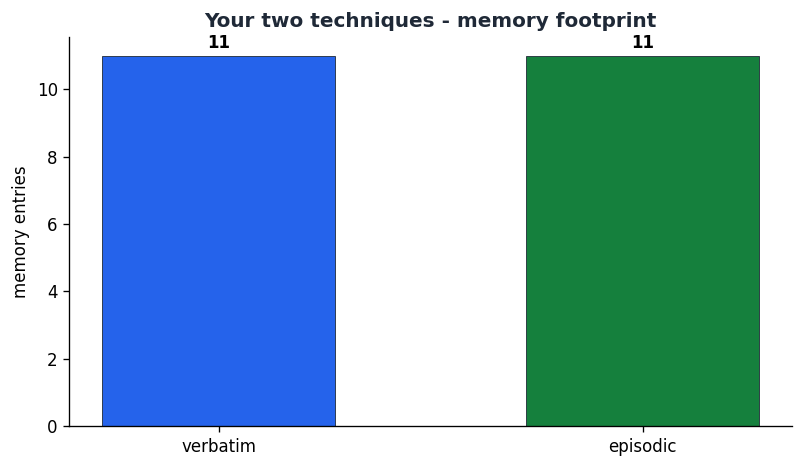

In [6]:
import matplotlib.pyplot as plt
try:
    names=[TECHNIQUE_1, TECHNIQUE_2]; turns=SUPPORT_TURNS
except NameError:
    names=["verbatim","episodic"]; turns=[("customer","Sarah Acme API 500 error"),("agent","connection pool issue")]
sizes=[]
for n in names:
    p=build_provider(n,emb,llm)
    p.ingest([MemoryRecord(f"t{i}",f"{w}: {t}",{"session":"s1"}) for i,(w,t) in enumerate(turns)])
    sizes.append(p.size())
fig,ax=plt.subplots(figsize=(6.8,4),dpi=120)
b=ax.bar(names,sizes,color=["#2563EB","#15803D"],edgecolor="#1F2937",linewidth=0.5,width=0.55)
for r,v in zip(b,sizes): ax.text(r.get_x()+r.get_width()/2,v+max(sizes)*0.02,str(v),ha="center",weight="bold")
ax.set_ylabel("memory entries")
ax.set_title("Your two techniques - memory footprint",color="#1F2937",weight="bold")
ax.spines[["top","right"]].set_visible(False); fig.tight_layout(); plt.show()